# **Transfer Learning với VGG16 cho Vietnamese Sign Language**


## **I. Import thư viện và thiết lập tham số**

In [14]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import numpy as np
import os

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **II. Cài đặt các thông số cơ bản (Hyperparameters)**

In [16]:
tfrecord_dir = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/data'

In [17]:
def get_dataset(path, batch_size=32):
    if not os.path.exists(path): return None

    # Cấu trúc feature
    features = {'image': tf.io.FixedLenFeature([], tf.string),
                'label': tf.io.FixedLenFeature([], tf.int64)}

    def parse(proto):
        parsed = tf.io.parse_single_example(proto, features)
        img = tf.image.resize(tf.io.decode_jpeg(parsed['image'], 3), [224, 224])
        return img, tf.cast(parsed['label'], tf.int32)

    return (tf.data.TFRecordDataset(path, "GZIP")
            .map(parse, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Khởi tạo nhanh các dataset bằng Dictionary Comprehension
paths = {s: os.path.join(tfrecord_dir, f"{s}.tfrecord") for s in ['train', 'val', 'test']}
datasets = {s: get_dataset(p) for s, p in paths.items()}

# Kiểm tra thử tập test
if datasets['test']:
    for imgs, lbls in datasets['test'].take(1):
        print(f"Thành công! Image shape: {imgs.shape}, Label shape: {lbls.shape}")

Thành công! Image shape: (32, 224, 224, 3), Label shape: (32,)


In [18]:
# Thông số mô hình
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 25
SEED = 42

print(f"Cấu hình:")
print(f"- Kích thước ảnh: {IMG_SIZE}")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Số lớp: {NUM_CLASSES}")

Cấu hình:
- Kích thước ảnh: (224, 224)
- Batch size: 32
- Số lớp: 25


## **III. Tải dữ liệu đã được chia sẵn**

In [19]:
print("Đang gán dữ liệu từ các tệp TFRecord đã đọc...")

train_ds = datasets['train']
val_ds = datasets['val']
test_ds = datasets['test']

print(f"\nTrạng thái dữ liệu:")
print(f"- Train dataset: {'Sẵn sàng' if train_ds else 'Lỗi'}")
print(f"- Val dataset: {'Sẵn sàng' if val_ds else 'Lỗi'}")
print(f"- Test dataset: {'Sẵn sàng' if test_ds else 'Lỗi'}")

Đang gán dữ liệu từ các tệp TFRecord đã đọc...

Trạng thái dữ liệu:
- Train dataset: Sẵn sàng
- Val dataset: Sẵn sàng
- Test dataset: Sẵn sàng


In [20]:
def count_actual_batches(ds, name):
    if ds:
        count = 0
        for _ in ds:
            count += 1
        print(f"- {name} (Thực tế): {count} batches")
    else:
        print(f"- {name}: Không có dữ liệu")

print("Đang đếm số lượng batches thực tế (quá trình này có thể mất ít phút...):")
count_actual_batches(train_ds, "Train dataset")
count_actual_batches(val_ds, "Val dataset")
count_actual_batches(test_ds, "Test dataset")

Đang đếm số lượng batches thực tế (quá trình này có thể mất ít phút...):
- Train dataset (Thực tế): 625 batches
- Val dataset (Thực tế): 78 batches
- Test dataset (Thực tế): 79 batches


## **IV. Tiền xử lý và tăng cường dữ liệu (Data Augmentation)**

In [21]:
# Hàm tiền xử lý cho VGG16
def preprocess_for_vgg16(image, label):
    image = preprocess_input(image)
    return image, label

# Hàm tăng cường dữ liệu
def augment_data(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    return image, label

# Áp dụng augmentation cho tập train
train_ds_augmented = train_ds.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_augmented = train_ds_augmented.map(preprocess_for_vgg16, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_augmented = train_ds_augmented.prefetch(tf.data.AUTOTUNE)

# Chỉ tiền xử lý cho tập val và test (không augmentation)
val_ds_processed = val_ds.map(preprocess_for_vgg16, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_processed = val_ds_processed.prefetch(tf.data.AUTOTUNE)

test_ds_processed = test_ds.map(preprocess_for_vgg16, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_processed = test_ds_processed.prefetch(tf.data.AUTOTUNE)

print("Đã áp dụng data augmentation và preprocessing.")

Đã áp dụng data augmentation và preprocessing.


## **V. Xây dựng mô hình với Transfer Learning**

In [24]:
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.models import Model

print("Đang khởi tạo mô hình VGG16 (Functional API)...")

# Lớp Input
inputs = Input(shape=(224, 224, 3))

# Tải mô hình VGG16 đã được huấn luyện trên ImageNet
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)

# Gắn "Đầu" mới cho 25 lớp
base_model.trainable = False

# Gắn "Đầu" mới cho 25 lớp
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Tổng kết Model
model = Model(inputs=inputs, outputs=outputs)

print(f"\nTổng số layers: {len(model.layers)}")

Đang khởi tạo mô hình VGG16 (Functional API)...

Tổng số layers: 23


In [25]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │        12,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,573,081 (105.18 MB)

 Trainable params: 12,858,393 (49.05 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## **VI. Giai đoạn 1: Warmup - Huấn luyện lớp đầu**

In [26]:
print("\n=== BẮT ĐẦU GIAI ĐOẠN 1: WARMUP ===")

# Hàm định nghĩa Learning Rate Warmup
def lr_warmup_scheduler(epoch, lr):
    warmup_epochs = 3
    target_lr = 1e-3
    if epoch < warmup_epochs:
        new_lr = target_lr * ((epoch + 1) / warmup_epochs)
        print(f"\n[Warmup] Epoch {epoch + 1}: Tăng LR lên {new_lr:.6f}")
        return new_lr
    else:
        print(f"\n[Warmup] Epoch {epoch + 1}: Giữ ổn định LR ở mức {target_lr:.6f}")
        return target_lr

warmup_callback = LearningRateScheduler(lr_warmup_scheduler)

# Biên dịch mô hình
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Huấn luyện 5 epoch chỉ với lớp đầu
history_stage1 = model.fit(
    train_ds_augmented,
    validation_data=val_ds_processed,
    epochs=5,
    callbacks=[warmup_callback]
)

print("\nHoàn tất Giai đoạn 1!")


=== BẮT ĐẦU GIAI ĐOẠN 1: WARMUP ===

[Warmup] Epoch 1: Tăng LR lên 0.000333
Epoch 1/5
    625/Unknown 149s 210ms/step - accuracy: 0.7870 - loss: 2.0840

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


625/625 ━━━━━━━━━━━━━━━━━━━━ 166s 238ms/step - accuracy: 0.8830 - loss: 0.8544 - val_accuracy: 0.9696 - val_loss: 0.1613 - learning_rate: 3.3333e-04

[Warmup] Epoch 2: Tăng LR lên 0.000667
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.9189 - loss: 0.9370 - val_accuracy: 0.9679 - val_loss: 0.3303 - learning_rate: 6.6667e-04

[Warmup] Epoch 3: Tăng LR lên 0.001000
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.9342 - loss: 1.0485 - val_accuracy: 0.9688 - val_loss: 0.4513 - learning_rate: 0.0010

[Warmup] Epoch 4: Giữ ổn định LR ở mức 0.001000
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 238ms/step - accuracy: 0.9574 - loss: 0.7512 - val_accuracy: 0.9784 - val_loss: 0.3182 - learning_rate: 0.0010

[Warmup] Epoch 5: Giữ ổn định LR ở mức 0.001000
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 149s 237ms/step - accuracy: 0.9622 - loss: 0.6581 - val_accuracy: 0.9832 - val_loss: 0.3014 - learning_rate: 0.0010

Hoàn tất Giai đoạn 1!


## **VII. Giai đoạn 2: Fine-tuning - Tinh chỉnh toàn bộ mô hình**

In [27]:
print("\n=== BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING ===")

# Rã đông mô hình
base_model.trainable = True

print(f"Số layers trainable sau khi unfreeze: {sum([1 for layer in model.layers if layer.trainable])}")

# Biên dịch lại mô hình với SGD, tốc độ học rất nhỏ
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Các Callback bảo vệ mô hình
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Huấn luyện sâu
history_stage2 = model.fit(
    train_ds_augmented,
    validation_data=val_ds_processed,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

print("\nHoàn tất Giai đoạn 2!")


=== BẮT ĐẦU GIAI ĐOẠN 2: FINE-TUNING ===
Số layers trainable sau khi unfreeze: 23
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 418s 587ms/step - accuracy: 0.9773 - loss: 0.2399 - val_accuracy: 0.9884 - val_loss: 0.1110 - learning_rate: 1.0000e-05
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 398s 594ms/step - accuracy: 0.9830 - loss: 0.0956 - val_accuracy: 0.9868 - val_loss: 0.1034 - learning_rate: 1.0000e-05
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 373s 596ms/step - accuracy: 0.9836 - loss: 0.0835 - val_accuracy: 0.9880 - val_loss: 0.0811 - learning_rate: 1.0000e-05
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 374s 598ms/step - accuracy: 0.9862 - loss: 0.0660 - val_accuracy: 0.9876 - val_loss: 0.0687 - learning_rate: 1.0000e-05
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 374s 598ms/step - accuracy: 0.9883 - loss: 0.0529 - val_accuracy: 0.9896 - val_loss: 0.0688 - learning_rate: 1.0000e-05
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 374s 599ms/step - accuracy: 0.9885 - loss: 0.0504 - val_accuracy: 0.9884 - va

## **VIII. Đánh giá mô hình trên tập Test**

In [28]:
print("\nĐang đánh giá mô hình trên tập Test...")

test_loss, test_accuracy = model.evaluate(test_ds_processed)

print(f"\n=== KẾT QUẢ TRÊN TẬP TEST ===")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Đang đánh giá mô hình trên tập Test...
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 281ms/step - accuracy: 0.9900 - loss: 0.0678

=== KẾT QUẢ TRÊN TẬP TEST ===
Test Loss: 0.0678
Test Accuracy: 0.9900 (99.00%)


## **IX. Vẽ biểu đồ quá trình huấn luyện**

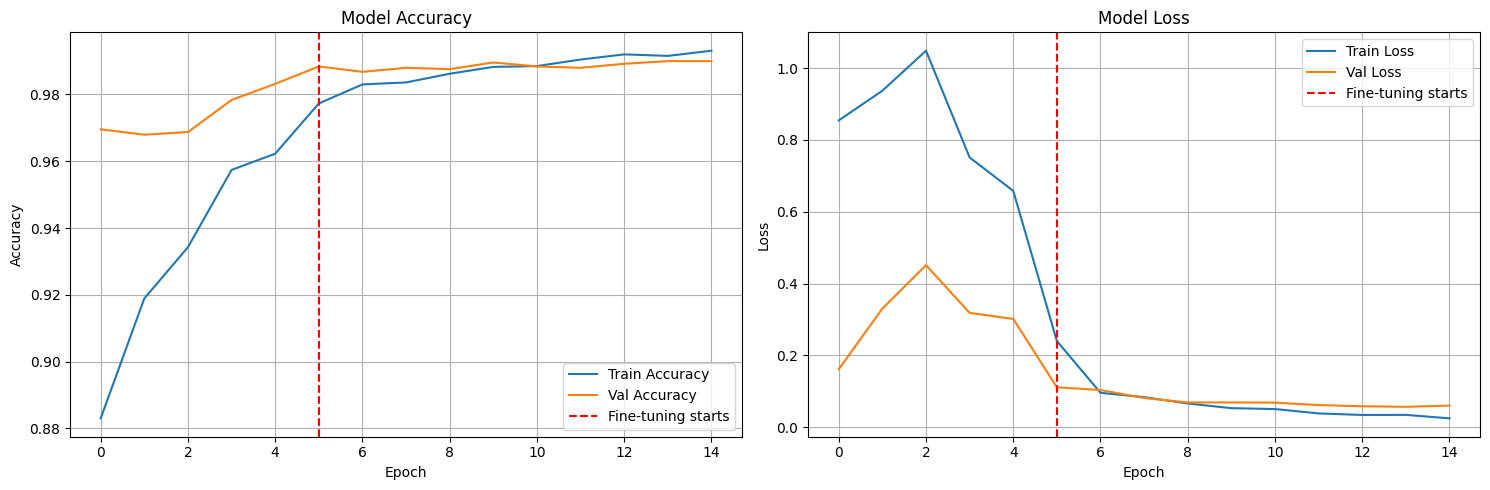

In [29]:
# Kết hợp lịch sử từ cả 2 giai đoạn
def combine_histories(hist1, hist2):
    combined = {}
    for key in hist1.history.keys():
        combined[key] = hist1.history[key] + hist2.history[key]
    return combined

full_history = combine_histories(history_stage1, history_stage2)

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(full_history['accuracy'], label='Train Accuracy')
axes[0].plot(full_history['val_accuracy'], label='Val Accuracy')
axes[0].axvline(x=5, color='red', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(full_history['loss'], label='Train Loss')
axes[1].plot(full_history['val_loss'], label='Val Loss')
axes[1].axvline(x=5, color='red', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## **X. Lưu mô hình**

In [30]:
# Lưu mô hình
model_save_path = '/content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/models/vgg16_vsl.keras'
model.save(model_save_path)

print(f"\nMô hình đã được lưu tại: {model_save_path}")
print("Hoàn tất!")


Mô hình đã được lưu tại: /content/drive/MyDrive/NTTU/HK2-2026/AI_2/Cuối kỳ/models/vgg16_vsl.keras
Hoàn tất!


## **XI. Kiểm tra dự đoán trên một số mẫu**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


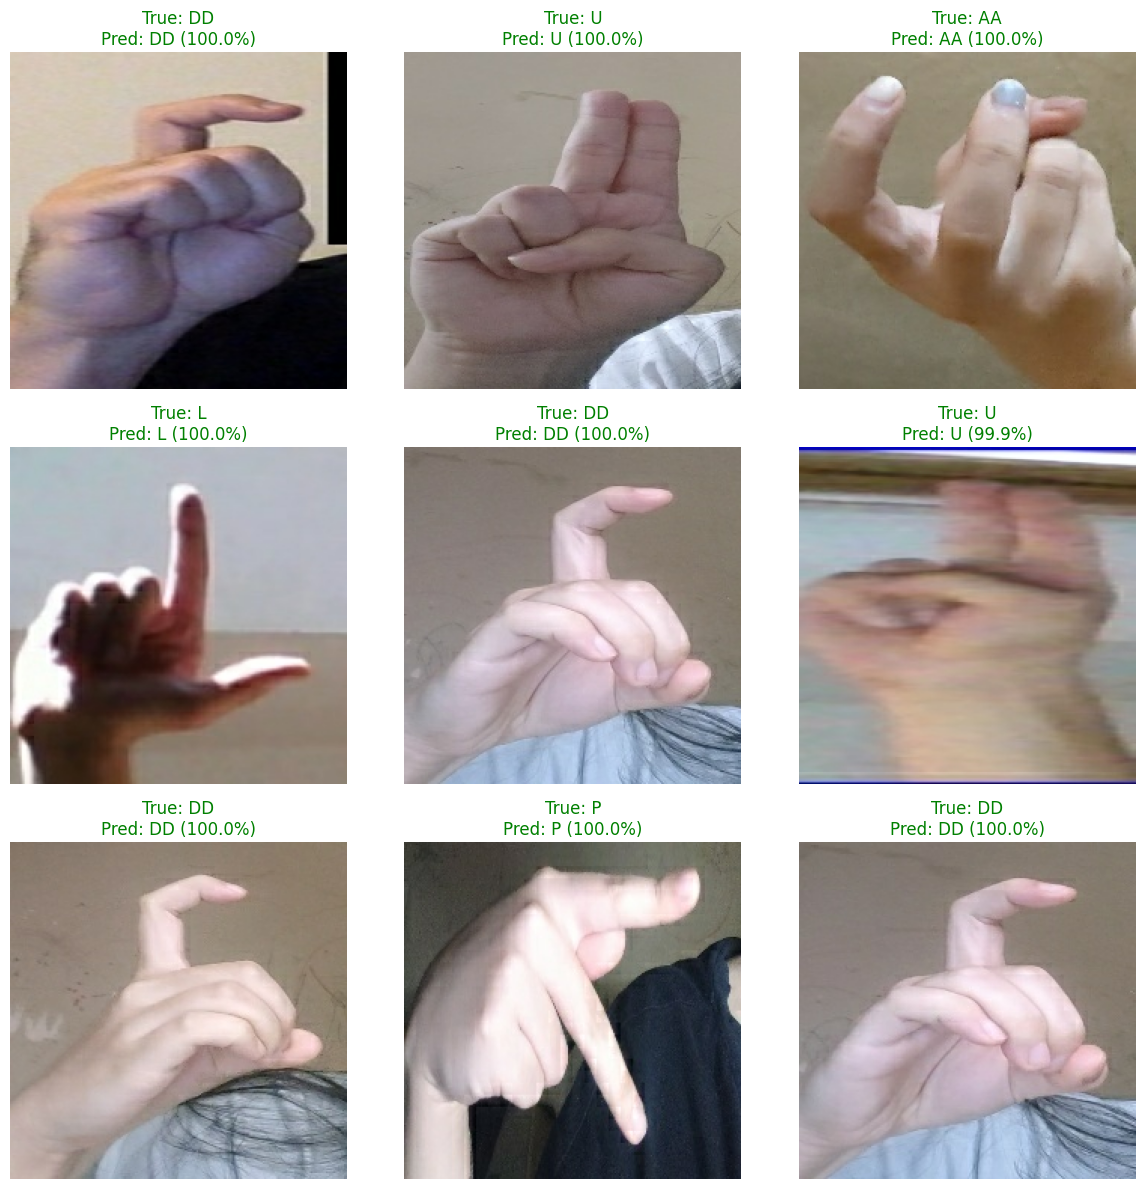

In [31]:
# Lấy tên các lớp
class_names = ['A', 'AA', 'B', 'C', 'D', 'DD', 'E', 'G', 'H', 'I', 'K', 'L', 'M',
               'N', 'O', 'OOO', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y']

# Lấy một batch từ tập test
for images, labels in test_ds.take(1):
    # Tiền xử lý ảnh
    processed_images = preprocess_input(images.numpy())

    # Dự đoán
    predictions = model.predict(processed_images)
    predicted_classes = np.argmax(predictions, axis=1)

    # Hiển thị 9 ảnh đầu tiên
    plt.figure(figsize=(12, 12))
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        true_label = class_names[labels[i].numpy()]
        pred_label = class_names[predicted_classes[i]]
        confidence = predictions[i][predicted_classes[i]] * 100

        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    break